In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from opensim_pendulum import OpenSimPendulum

In [2]:
model = OpenSimPendulum()
model._use_gravity = False
model._with_contact = False
model.initialize(0.0)

In [3]:
# viz = osim.VisualizerUtilities()
# viz.showModel(model.model)

In [ ]:
# Analytical solution
L = model.parameters['Model']['length']
m = model.parameters['Model']['mass']
I = m * L**2
q0 = model.parameters['InitialConditions']['q0']
omega0 = model.parameters['InitialConditions']['omega0']

def analytic_step(dt, q, omega, torque, I):
    alpha = torque / I
    q_next = q + omega * dt + 0.5 * alpha * dt**2
    omega_next = omega + alpha * dt
    return q_next, omega_next, alpha

def determine_torque(t, t_end, torque=1.0):
    interval = t_end / 6 
    if t < interval:
        return t * torque
    elif t < 2 * interval:
        return interval * torque
    elif t < 3 * interval:
        return interval * torque - (t - 2 * interval) * torque
    elif t < 4 * interval:
        return -(t - 3 * interval) * torque
    elif t < 5 * interval:
        return -(interval) * torque
    else:
        return -interval * torque + (t - 5 * interval) * torque

In [ ]:
t = 0.0
dt = 0.01
t_end = 1

t_vals = [t]
q_vals = [q0]
a_vals = [omega0]
w_vals = [0.0]

q_an_vals = [q0]
w_an_vals = [omega0]
alpha_an_vals = [0.0]

torque_val = 1
q_an = q0
omega_an = omega0

while t < t_end:
    torque = determine_torque(t, t_end, torque=torque_val)
    
    # Compute analytical solution
    q_an, omega_an, alpha_an = analytic_step(dt, q_an, omega_an, torque, I)
    
    # Perform simulation step
    model.set_inputs({'torque':torque}, t)
    model.do_step(t, dt)
    t_next = t + dt

    a_vals.append(model.outputs['alpha'].get())
    w_vals.append(model.outputs['omega'].get())
    q_vals.append(model.outputs['q'].get())

    q_an_vals.append(q_an)
    w_an_vals.append(omega_an)
    alpha_an_vals.append(alpha_an)

    t_vals.append(t_next)
    t = t_next

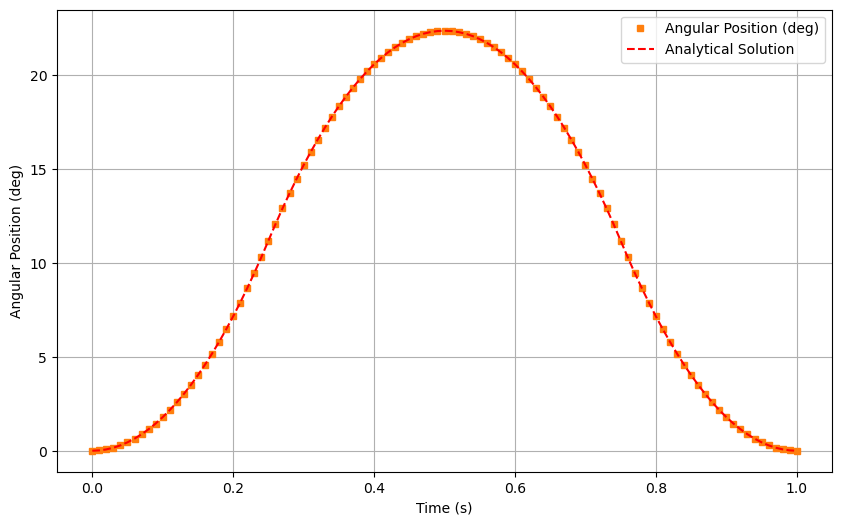

Final Angle (deg): 6.031956353067727×10⁻¹³ deg


In [10]:
marker_size = 4
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_vals), label='Angular Position (deg)', **opensim_style)
plt.plot(t_vals, np.rad2deg(q_an_vals), label='Analytical Solution', linestyle='--', color='r')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (deg)')
plt.grid()
plt.legend()
plt.show()

print(f"Final Angle (deg): {np.rad2deg(model.outputs['q'].get())}")

In [11]:
model.save_model('os_pendulum.osim')